# Plotting Slopes of Extreme Precip Cell Properties 

## Load Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import xarray as xr
import sys

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns



# load tool set
sys.path.append("../tools")
import plotting
import monthly_data_vars_meta
import imports

## Load data

In [2]:
# dir to data
main_directory = '/work/bb1376/user/leonie/paper_update/output/data_slopes_10_alpha'

### Data for different threshold definitions (experiments/variants)

In [3]:
# data => for left figure
df1 = pd.read_csv(f'{main_directory}/df_lm_coefficients_boot_10_percent_contribution_all_relative.csv')
df2 = pd.read_csv( f'{main_directory}/df_lm_coefficients_boot_30_percent_contribution_all_relative.csv')
df3 = pd.read_csv( f'{main_directory}/df_lm_coefficients_boot_50_percent_contribution_all_relative.csv')
df4 = pd.read_csv( f'{main_directory}/df_lm_coefficients_boot_500_mm_all_relative.csv')
df5 = pd.read_csv( f'{main_directory}/df_lm_coefficients_boot_200_mm_all_relative.csv')
df6 = pd.read_csv( f'{main_directory}/df_lm_coefficients_boot_80_mm_all_relative.csv')


# variant labels
df1['variant'] = '90 %'
df2['variant'] = '70 %'
df3['variant'] = '50 %'
df4['variant'] = '500 mm'
df5['variant'] = '200 mm'
df6['variant'] = '80 mm'


# combine
df_all = pd.concat([df1, df2,df3,df4,df5,df6])

# xarray
ds = df_all.set_index(['variant','variable']).to_xarray()

# variable names (for function 
rename_map = {'area_mean': 'area_cell_mean', 'total_mean': 'total_cell_mean',"max_mean":"max_cell_mean",
              "n_cells":"sum_counts","rain_cell_sum":"total_sum","cell_area_sum":"area_sum"}
ds = ds.assign_coords(
    variable=[rename_map.get(v, v) for v in ds['variable'].values]
)
ds

<xarray.Dataset> Size: 3kB
Dimensions:          (variant: 6, variable: 6)
Coordinates:
  * variant          (variant) object 48B '200 mm' '50 %' ... '80 mm' '90 %'
  * variable         (variable) <U15 360B 'area_cell_mean' ... 'total_cell_mean'
Data variables:
    slope_point      (variant, variable) float64 288B 0.03441 ... 0.07017
    intercept_point  (variant, variable) float64 288B -9.28 -7.769 ... -19.97
    slope            (variant, variable) float64 288B 0.03464 0.02957 ... 0.0701
    intercept        (variant, variable) float64 288B -9.348 -7.835 ... -19.95
    slope_ci_lower   (variant, variable) float64 288B 0.0257 0.02522 ... 0.05663
    slope_ci_upper   (variant, variable) float64 288B 0.04416 ... 0.08414
    year_min         (variant, variable) int64 288B 2021 2021 2021 ... 2021 2021
    year_max         (variant, variable) int64 288B 2049 2049 2049 ... 2049 2049

### Data for 10 % contribution 

In [4]:
# data =>  for right figure 
experiment =  "10_percent_contribution" #experiment # from import defs
name_experiment = "90% contribution"

# dir with paths
csv_info= {
    'All': f'{main_directory}/df_lm_coefficients_boot_{experiment}_all_relative.csv',
    'Ocean': f'{main_directory}/df_lm_coefficients_boot_{experiment}_ocean_relative.csv',
    'Land': f'{main_directory}/df_lm_coefficients_boot_{experiment}_land_relative.csv'
}
# read and convert to xarray dataset
ds_sub = imports.read_slopes_csv_as_ds(csv_info)

# variable names (for function 
ds_sub = ds_sub.assign_coords(
    variable=[rename_map.get(v, v) for v in ds_sub['variable'].values]
)
ds_sub

<xarray.Dataset> Size: 2kB
Dimensions:          (variant: 3, variable: 6)
Coordinates:
  * variant          (variant) object 24B 'All' 'Land' 'Ocean'
  * variable         (variable) <U15 360B 'area_cell_mean' ... 'total_cell_mean'
Data variables:
    slope_point      (variant, variable) float64 144B -0.00886 ... 0.05581
    intercept_point  (variant, variable) float64 144B 3.648 25.06 ... -15.7
    slope            (variant, variable) float64 144B -0.008177 ... 0.05605
    intercept        (variant, variable) float64 144B 3.443 24.48 ... -15.77
    slope_ci_lower   (variant, variable) float64 144B -0.01913 ... 0.04054
    slope_ci_upper   (variant, variable) float64 144B 0.002942 ... 0.07115
    year_min         (variant, variable) int64 144B 2021 2021 2021 ... 2021 2021
    year_max         (variant, variable) int64 144B 2049 2049 2049 ... 2049 2049

## Plotting

In [5]:
# label info from metadata 
VAR_META = monthly_data_vars_meta.VAR_META_ANNUAL


# order of variables 
variable_order = ['max_cell_mean','total_cell_mean','area_cell_mean','total_sum',"sum_counts","area_sum"]
variable_labels = ['Cell density','Total precip./cell','Max. precip./cell','Area/cell','Total precip.']


# order of experiments
variant_order = ['90 %','70 %', '50 %','500 mm','200 mm','80 mm']



# hatches
base_hatches = {'mm':'...', 'contri':'','All':''} 

# for left plot
hatches = {
    '90 %': base_hatches["contri"],
    '70 %': base_hatches["contri"],
    '50 %': base_hatches["contri"],
    '500 mm': base_hatches["mm"],
    '200 mm': base_hatches["mm"],
    '80 mm': base_hatches["mm"],
          }

# right plot
hatches_surface = {'All': base_hatches["All"], 
                   "Ocean":base_hatches["All"], 
                   'Land': base_hatches["All"]}


# colors
set2 = plt.get_cmap("Set2").colors

# left plot
colors = {
    '90 %': set2[1],
    '500 mm': set2[3],

    '70 %': set2[0],
    '200 mm': set2[4],

    '50 %': set2[2],
    '80 mm': set2[5],}


# right plot
colors_surface = {
    'All': set2[1],
    'Ocean': '#1f77b4',
    'Land':'#2ca02c'}

## Joined Plot

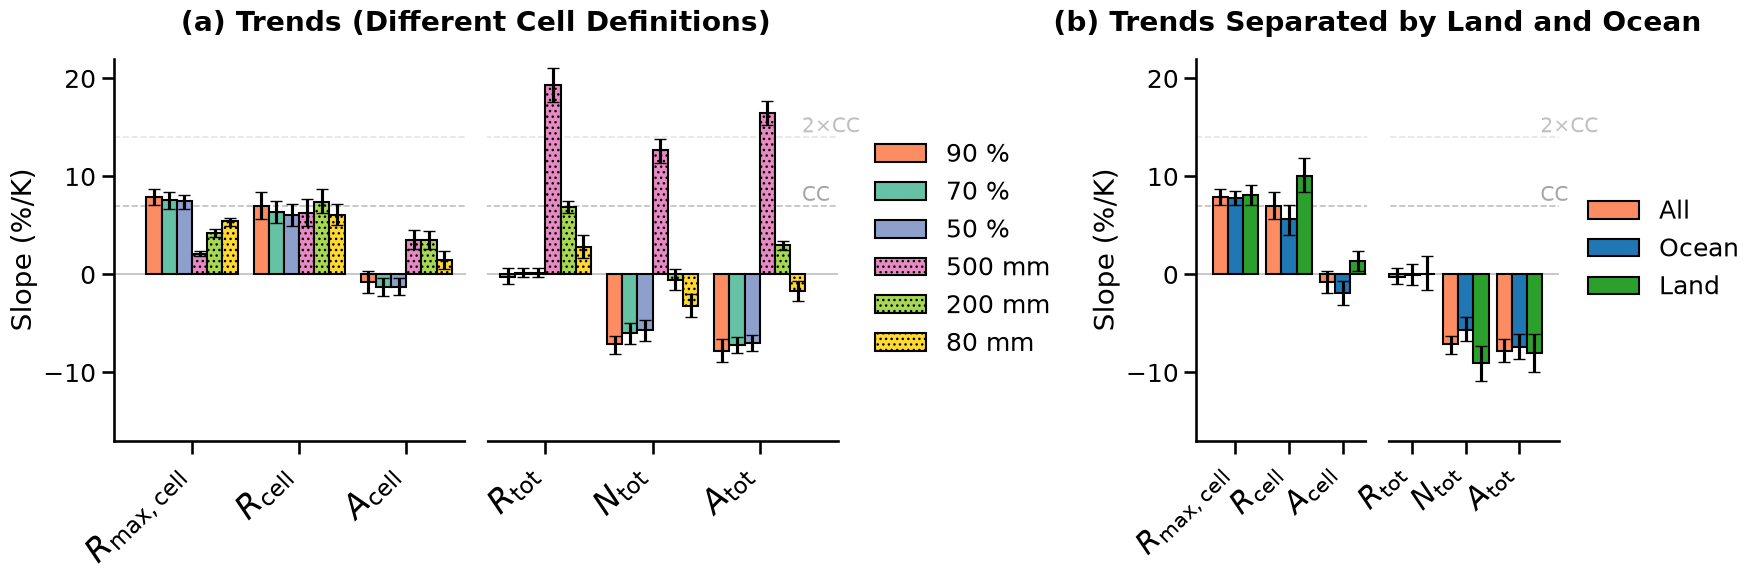

In [7]:
sns.set_context("talk",font_scale = 1.1)
fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], figure=fig)

axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

plotting.plot_slope_comparison(
    ds=ds,
    variable_order=variable_order,
    variant_order=variant_order,
    VAR_META=VAR_META,
    hatches=hatches,
    colors = colors,
    ylabel='Slope (%/K)',
    ylim=(-17, 22),
    title=f'{int(ds.year_min[0][0].values)}-{int(ds.year_max[0][0].values)}',
    ax_passed=axes[0],   
    xaxislabelscale = 1.3
    
)

plotting.plot_slope_comparison(
    ds=ds_sub,
    variable_order=variable_order,
    variant_order=['All','Ocean','Land'],
    VAR_META=VAR_META,
    colors=colors_surface,
    hatches=hatches_surface,
    ylabel='Slope (%/K)',
    title=name_experiment,
    ylim=(-17, 22),
    ax_passed=axes[1],          
)

axes[0].set_title('(a) Trends (Different Cell Definitions)', fontweight = 'bold', pad = 20)
axes[1].set_title('(b) Trends Separated by Land and Ocean', fontweight = 'bold', pad = 20)

#plt.savefig("./fig3.jpg",bbox_inches="tight")
plt.show()